In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ieeg.auth import Session
from scipy import signal
import mne
import json
import pandas as pd
import os
import re
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from multiprocessing import Pool
import scipy.stats as stats
import ast

# Import custom functions
import sys, os
code_v3_path = os.path.dirname('/mnt/leif/littlab/users/aguilac/Interictal_Spike_Analysis/HUMAN/spike_detector/')
sys.path.append(code_v3_path)
from spike_detector import *
from iEEG_helper_functions import *
from spike_morphology_v2 import *

code_path = os.path.dirname('/mnt/leif/littlab/users/aguilac/Interictal_Spike_Analysis/HUMAN/working_feat_extract_code/functions/')
sys.path.append(code_path)
from ied_fx_v3 import *

import sys, os
code_v2_path = os.path.dirname('../Ei/')
sys.path.append(code_v2_path)
from utils import get_iEEG_data, notch_filter

In [2]:
#load in the datasets

hup_ei1 = pd.read_csv('../data/self_run/EI_new_onset_detector/EI_HUP_40_60s.csv') #This is v=1, t=1000
hup_ei2 = pd.read_csv('../data/self_run/EI_new_onset_detector/EI_HUP_v0-5.csv') #This is v=0.5, t=1000
hup_ei3 = pd.read_csv('../data/self_run/EI_new_onset_detector/EI_HUP_v1-5.csv') #This is v=1.5, t=1000
hup_ei4 = pd.read_csv('../data/self_run/EI_new_onset_detector/EI_HUP_t1500.csv') #This is v=1, t=1500
hup_ei5 = pd.read_csv('../data/self_run/EI_new_onset_detector/EI_HUP_t2000.csv') #This is v=1, t=2000

In [3]:
dataframes = [hup_ei1, hup_ei2, hup_ei3, hup_ei4, hup_ei5]
df_names = ['hup_ei1', 'hup_ei2', 'hup_ei3', 'hup_ei4', 'hup_ei5']

# Combine all dataframes
for i, df in enumerate(dataframes):
    df['source_df'] = df_names[i]

combined_df = pd.concat(dataframes, ignore_index=True)

# Sort the combined dataframe
combined_df = combined_df.sort_values(['hupID', 'ictal_start_time'])

In [4]:
def print_random_patient_onset_info(df):
    # Get a list of unique hupID values
    unique_hup_ids = df['hupID'].unique()
    
    # Randomly select a hupID
    random_hup_id = random.choice(unique_hup_ids)
    
    # Get all rows for this hupID
    patient_rows = df[df['hupID'] == random_hup_id]
    
    # Get a list of unique ictal_start_time values for this hupID
    ictal_start_times = patient_rows['ictal_start_time'].unique()
    
    # Randomly select an ictal_start_time
    random_ictal_start_time = random.choice(ictal_start_times)
    
    print(f"Randomly selected hupID: {random_hup_id}")
    print(f"Randomly selected ictal_start_time: {random_ictal_start_time}")
    print("=" * 70)
    
    # Filter rows for the selected hupID and ictal_start_time
    selected_rows = patient_rows[patient_rows['ictal_start_time'] == random_ictal_start_time]
    
    # Create a summary dataframe
    summary = selected_rows[['source_df', 'onset_algorithm', 'onset_ch']].set_index('source_df')
    
    # Print the summary
    print(summary)
    print("=" * 70)
    
    # Check if onset_algorithm and onset_ch are consistent across dataframes
    algo_consistent = summary['onset_algorithm'].nunique() == 1
    ch_consistent = summary['onset_ch'].nunique() == 1
    
    print(f"onset_algorithm consistent across dataframes: {'Yes' if algo_consistent else 'No'}")
    print(f"onset_ch consistent across dataframes: {'Yes' if ch_consistent else 'No'}")

# Example usage:
print_random_patient_onset_info(combined_df)

Randomly selected hupID: HUP163
Randomly selected ictal_start_time: 585827.0
           onset_algorithm  onset_ch
source_df                           
hup_ei1            15105.0         8
hup_ei2            15070.0         8
hup_ei3            15136.0         8
hup_ei4            17120.0         0
hup_ei5            17169.0         0
onset_algorithm consistent across dataframes: No
onset_ch consistent across dataframes: No


In [11]:
grouped = combined_df.groupby(['hupID', 'ictal_start_time'])
differences = []

for (hup_id, ictal_time), group in grouped:
        row = {'hupID': hup_id, 'ictal_start_time': ictal_time}
        
        hup_ei1_algo = group[group['source_df'] == 'hup_ei1']['onset_algorithm'].values
        if len(hup_ei1_algo) == 0:
            continue
        hup_ei1_algo = str(hup_ei1_algo[0])
        print(hup_ei1_algo)

37640.0
25872.0
24879.0
50000.0
18400.0
50000.0
50000.0
20539.0
50000.0
48808.0
37971.0
13130.0
50000.0
13623.0
41372.0
28427.0
26494.0
23890.0
24645.0
42878.0
50000.0
50000.0
32791.0
43609.0
49840.0
3913.0
34589.0
1200.0
28378.0
24553.0
25899.0
10442.0
50000.0
5425.0
2182.0
12041.0
2270.0
681.0
14332.0
1212.0
50000.0
5709.0
2237.0
2096.0
22410.0
10538.0
5575.0
2938.0
324.0
5265.0
18103.0
761.0
12509.0
440.0
50000.0
1848.0
30070.0
7751.0
4892.0
33092.0
50000.0
11066.0
10458.0
50000.0
50000.0
50000.0
1582.0
8297.0
4217.0
37402.0
7427.0
17524.0
50000.0
50000.0
8314.0
8071.0
50000.0
50000.0
10536.0
48429.0
1061.0
16711.0
1213.0
5547.0
1802.0
3184.0
4286.0
5587.0
10687.0
44504.0
50000.0
27227.0
50000.0
50000.0
21460.0
50000.0
16694.0
10076.0
50000.0
50000.0
16496.0
22660.0
5849.0
2516.0
14843.0
7861.0
22458.0
8054.0
21146.0
1094.0
1574.0
2185.0
21670.0
22788.0
50000.0
7369.0
292.0
8758.0
50000.0
17638.0
18581.0
44602.0
50000.0
4939.0
340.0
11115.0
6430.0
21233.0
2743.0
3524.0
596.0
3489.0


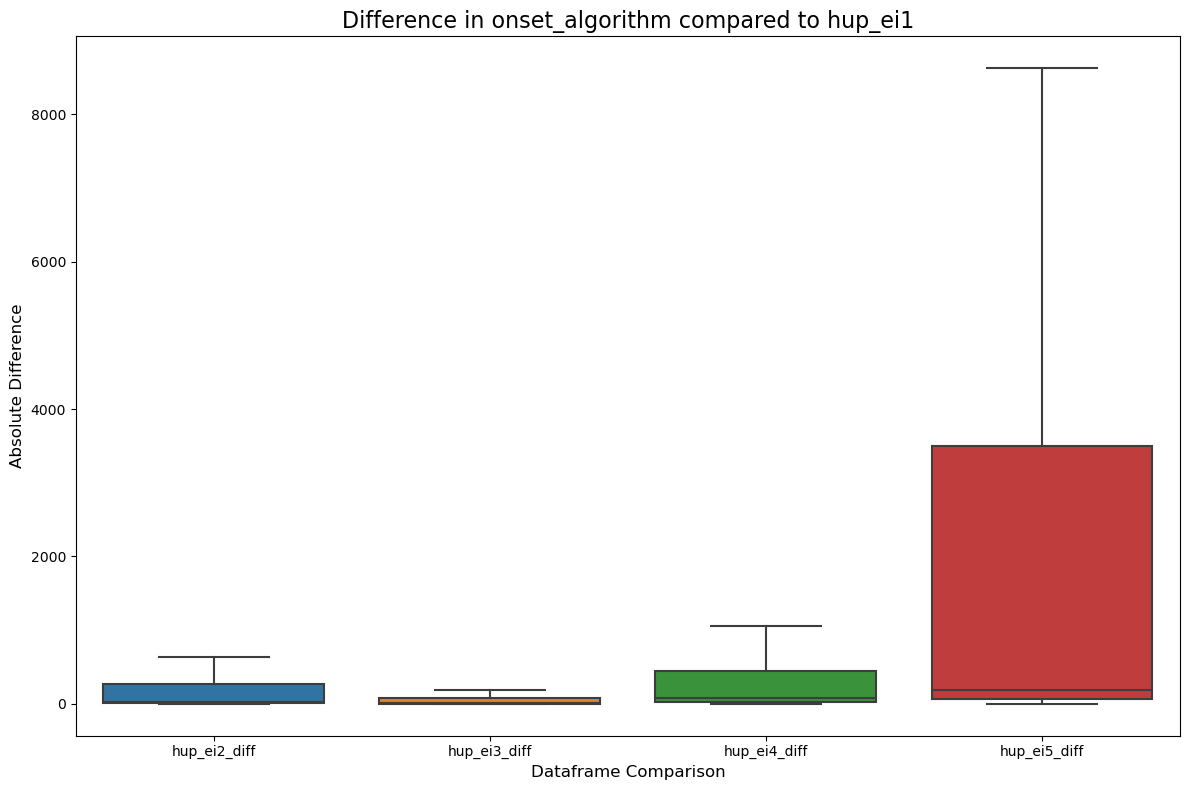

In [24]:
def calculate_algorithm_differences(df):
    grouped = df.groupby(['hupID', 'ictal_start_time'])
    
    differences = []
    
    for (hup_id, ictal_time), group in grouped:
        row = {'hupID': hup_id, 'ictal_start_time': ictal_time}
        
        hup_ei1_algo = group[group['source_df'] == 'hup_ei1']['onset_algorithm'].values
        if len(hup_ei1_algo) == 0:
            continue
        hup_ei1_algo = int(hup_ei1_algo[0])  # Convert to int
        
        for i in range(2, 6):
            df_name = f'hup_ei{i}'
            algo = group[group['source_df'] == df_name]['onset_algorithm'].values
            if len(algo) > 0:
                algo = int(algo[0])  # Convert to int
                diff = abs(hup_ei1_algo - algo)  # Calculate absolute difference
                row[f'{df_name}_diff'] = diff
            else:
                row[f'{df_name}_diff'] = np.nan
        
        differences.append(row)
    
    return pd.DataFrame(differences)

def plot_algorithm_differences_with_points(diff_df):
    diff_columns = ['hup_ei2_diff', 'hup_ei3_diff', 'hup_ei4_diff', 'hup_ei5_diff']
    
    melted_df = diff_df.melt(id_vars=['hupID', 'ictal_start_time'], 
                             value_vars=diff_columns, 
                             var_name='comparison', 
                             value_name='difference')
    
    plt.figure(figsize=(12, 8))

    # Then add barplot
    sns.boxplot(x='comparison', y='difference', data=melted_df, notch = False, showfliers = False)
    
    # Add stripplot first
    # sns.stripplot(x='comparison', y='difference', data=melted_df, 
                #   color='black', alpha=0.5, jitter=True, zorder=1)
    
    plt.title('Difference in onset_algorithm compared to hup_ei1', fontsize=16)
    plt.xlabel('Dataframe Comparison', fontsize=12)
    plt.ylabel('Absolute Difference', fontsize=12)
    
    # for i, comparison in enumerate(diff_columns):
    #     mean_val = melted_df[melted_df['comparison'] == comparison]['difference'].mean()
    #     plt.text(i, mean_val, f'{mean_val:.2f}', ha='center', va='bottom')
    
    # Print summary statistics
    # print(melted_df['difference'].describe())
    
    # Adjust y-axis to show full range
    # plt.ylim(0, melted_df['difference'].max() * 1.1)
    
    plt.tight_layout()
    plt.show()

# Calculate differences
diff_df = calculate_algorithm_differences(combined_df)

# Display the first few rows and summary statistics of the difference dataframe
# print(diff_df.head())
# print(diff_df.describe())

# Plot the differences with individual points
plot_algorithm_differences_with_points(diff_df)